In [1]:
import os
os.environ["KAGGLE USERNAME"] = "mohammedhasan11234"
os.environ["KAGGLE KEY"] = "KGAT_12eeb694e27fa5289f371e88c156998a"

In [2]:
!kaggle datasets download -d "vencerlanz09/pharmaceutical-drugs-and-vitamins-synthetic-images"

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/pharmaceutical-drugs-and-vitamins-synthetic-images
License(s): CC-BY-SA-3.0
100% 238M/238M [00:14<00:00, 17.3MB/s]



In [3]:
!unzip "/content/pharmaceutical-drugs-and-vitamins-synthetic-images.zip"

Streaming output truncated to the last 5000 lines.
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005001.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005002.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005003.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005004.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005005.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005006.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005007.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005008.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005009.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005010.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005011.jpg  
  inflating: ImageClassesCombinedWithCOCOAnnotations/images_raw/00005012.jpg  
 

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [5]:
dataset_path = "/content/Drug Vision/Data Combined"
print(os.listdir(dataset_path))

['Bactidol', 'Medicol', 'DayZinc', 'Kremil S', 'Fish Oil', 'Biogesic', 'Alaxan', 'Bioflu', 'Neozep', 'Decolgen']


In [6]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [7]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.


In [8]:
class_names = train_dataset.class_names
print("Number of Classes :", len(class_names))
print("\nClasses\n")
for i, name in enumerate(class_names):
    print(i, ":", name)

Number of Classes : 10

Classes

0 : Alaxan
1 : Bactidol
2 : Bioflu
3 : Biogesic
4 : DayZinc
5 : Decolgen
6 : Fish Oil
7 : Kremil S
8 : Medicol
9 : Neozep


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

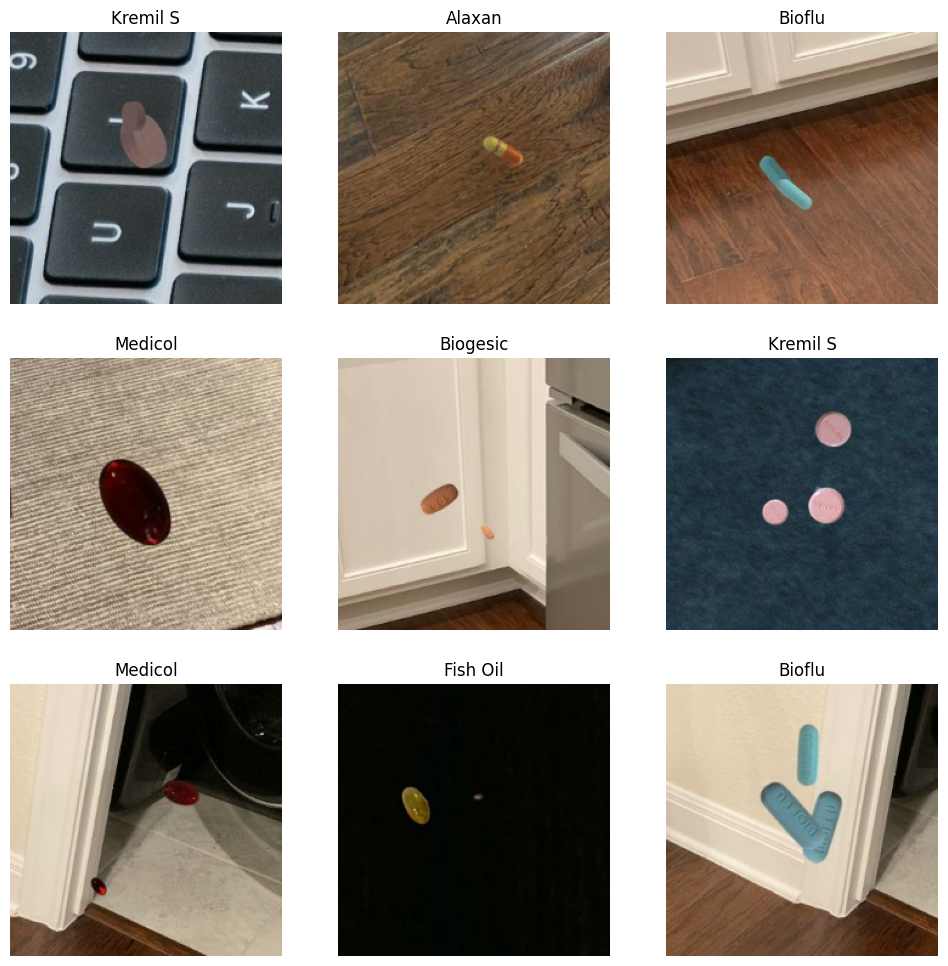

In [10]:
plt.figure(figsize=(12,12))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [11]:
print("Training Batches :", len(train_dataset))
print("Validation Batches :", len(validation_dataset))

Training Batches : 250
Validation Batches : 63


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),],
    name="data_augmentation")

In [13]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3))
base_model.trainable = False
print("EfficientNetB0 Loaded Successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 Loaded Successfully


In [14]:
inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names),activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
print("Output Shape :", model.output_shape)
print("Number of Classes :", len(class_names))

Output Shape : (None, 10)
Number of Classes : 10


In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [17]:
checkpoint = ModelCheckpoint("best_pill_model.keras",monitor="val_accuracy",save_best_only=True,mode="max",verbose=1)
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True,verbose=1)

In [18]:
history = model.fit(train_dataset,validation_data=validation_dataset,epochs=20,callbacks=[checkpoint, early_stop])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2315 - loss: 2.1778
Epoch 1: val_accuracy improved from None to 0.71750, saving model to best_pill_model.keras

Epoch 1: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.3625 - loss: 1.9064 - val_accuracy: 0.7175 - val_loss: 1.2295
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6021 - loss: 1.3073
Epoch 2: val_accuracy improved from 0.71750 to 0.78650, saving model to best_pill_model.keras

Epoch 2: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6394 - loss: 1.1920 - val_accuracy: 0.7865 - val_loss: 0.7815
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7113 - loss: 0.9596
Epoch 3: val_accuracy improved from 0.78650 to 0.82300, saving model to best_pill_model.keras

Epoch 3: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accur

In [19]:
model.save("pill_identification_model.keras")
print("Model Saved Successfully")
print(history.history.keys())

Model Saved Successfully
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


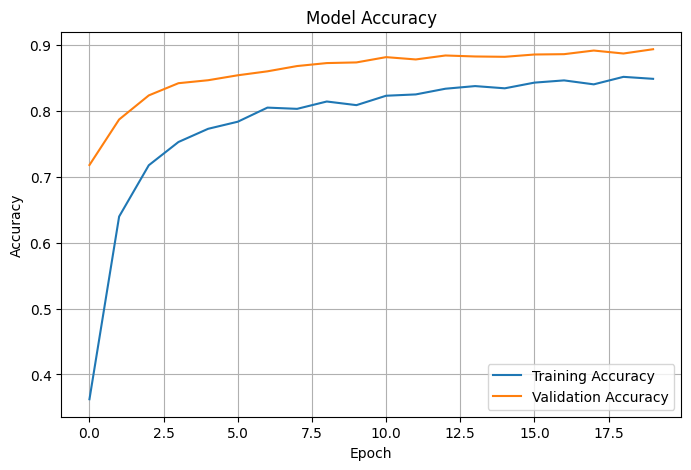

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
loss, accuracy = model.evaluate(validation_dataset)
print("="*40)
print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy*100,"%")
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8930 - loss: 0.3166
Validation Loss : 0.31656959652900696
Validation Accuracy : 89.30000066757202 %


In [22]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [23]:
y_true = []
y_pred = []
for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [24]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

      Alaxan       0.91      0.91      0.91       202
    Bactidol       0.92      0.88      0.90       198
      Bioflu       0.85      0.88      0.86       189
    Biogesic       0.87      0.81      0.84       194
     DayZinc       0.86      0.90      0.88       197
    Decolgen       0.96      0.94      0.95       200
    Fish Oil       0.92      0.95      0.93       200
    Kremil S       0.88      0.92      0.90       219
     Medicol       0.95      0.95      0.95       201
      Neozep       0.82      0.78      0.80       200

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



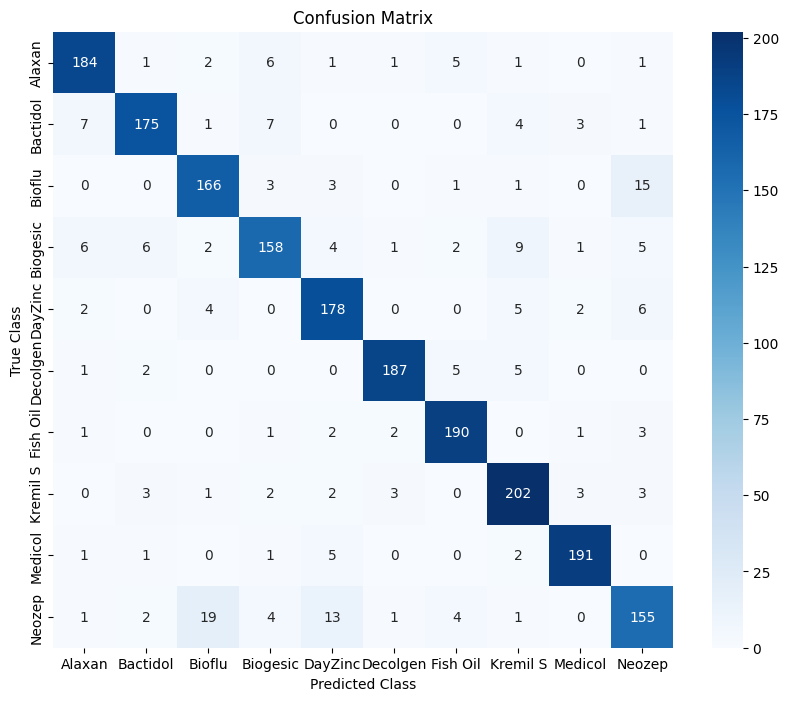

In [25]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

In [26]:
model.save("pill_identification_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [27]:
import tensorflow as tf
model = tf.keras.models.load_model("pill_identification_model.keras")
print("Model Loaded Successfully")

Model Loaded Successfully


In [28]:
loss, accuracy = model.evaluate(validation_dataset)
print(f"Accuracy : {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.8930 - loss: 0.3166
Accuracy : 89.30%


In [29]:
model.save("Pill_Identification_final.keras")

In [32]:
import tensorflow as tf

KERAS_MODEL_PATH = "/content/Pill_Identification_final.keras"
TFLITE_OUTPUT_PATH = "Pill_Identification.tflite"

print(f"Loading {KERAS_MODEL_PATH} ...")
model = tf.keras.models.load_model(KERAS_MODEL_PATH)

print("Converting to TFLite (this can take a minute)...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(TFLITE_OUTPUT_PATH, "wb") as f:
    f.write(tflite_model)

import os
size_mb = os.path.getsize(TFLITE_OUTPUT_PATH) / (1024 * 1024)
print(f"Done. Wrote {TFLITE_OUTPUT_PATH} ({size_mb:.2f} MB)")
print("Copy this .tflite file into your Flask project folder for deployment.")

Loading /content/Pill_Identification_final.keras ...
Converting to TFLite (this can take a minute)...
Saved artifact at '/tmp/tmpsd4cl60w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  131917708563024: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131917708566096: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131924763965200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924763963856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924763963664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924763966928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924763962896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927001996688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924763967312: TensorSpec(shap